In [2]:
import torch
print(f"Có GPU không? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Tên GPU: {torch.cuda.get_device_name(0)}")

Có GPU không? True
Tên GPU: NVIDIA GeForce RTX 5060 Laptop GPU


G:\url-analysis\.venv\Lib\site-packages\torch\cuda\__init__.py:235: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


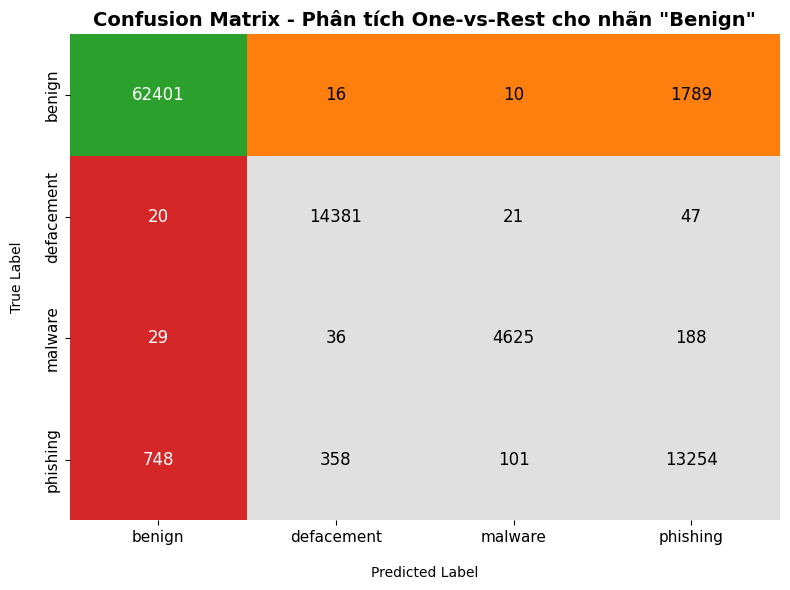

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.colors import ListedColormap

# 1. Dữ liệu confusion matrix của bạn
labels = ['benign', 'defacement', 'malware', 'phishing']
cm = np.array([
    [62401, 16, 10, 1789],
    [20, 14381, 21, 47],
    [29, 36, 4625, 188],
    [748, 358, 101, 13254]
])

# 2. Định nghĩa màu sắc (Xanh lục: TP, Đỏ: FP, Cam: FN, Xám: TN)
colors = {
    'TP': '#2ca02c', # Green
    'FP': '#d62728', # Red
    'FN': '#ff7f0e', # Orange
    'TN': '#e0e0e0'  # Light Gray
}

# 3. Chọn nhãn để làm nổi bật (ví dụ: 'benign' -> chỉ mục 0)
label_index = 0
selected_label = labels[label_index]

# 4. Tạo ma trận màu sắc và mặt nạ vùng
# Tạo ma trận giá trị (0: TP, 1: FP, 2: FN, 3: TN)
region_matrix = np.full((len(labels), len(labels)), 3) # Mặc định TN
region_matrix[label_index, label_index] = 0 # TP
# FP (cột)
for i in range(len(labels)):
    if i != label_index:
        region_matrix[i, label_index] = 1
# FN (hàng)
for j in range(len(labels)):
    if j != label_index:
        region_matrix[label_index, j] = 2

# 5. Tạo colormap tùy chỉnh
cmap_custom = ListedColormap([colors['TP'], colors['FP'], colors['FN'], colors['TN']])

# 6. Vẽ Ma trận
fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ heatmap màu nền trước
cax = sns.heatmap(region_matrix, annot=False, cmap=cmap_custom, vmin=0, vmax=3, cbar=False, ax=ax)

# Phủ số liệu lên trên với màu chữ tương phản
for i in range(len(labels)):
    for j in range(len(labels)):
        cell_value = cm[i, j]
        # Chọn màu chữ có độ tương phản cao
        text_color = "black" if (region_matrix[i, j] == 2 or region_matrix[i, j] == 3) else "white"
        ax.text(j + 0.5, i + 0.5, str(cell_value), va='center', ha='center', fontsize=12, color=text_color)

# 7. Định cấu hình trục và chú thích
ax.set_xticks(np.arange(len(labels)) + 0.5)
ax.set_yticks(np.arange(len(labels)) + 0.5)
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Predicted Label', labelpad=15)
ax.set_ylabel('True Label', labelpad=15)
ax.set_title(f'Confusion Matrix - Phân tích One-vs-Rest cho nhãn "{selected_label.capitalize()}"', fontsize=14, fontweight='bold')
ax.grid(False)

plt.tight_layout()
plt.show()